In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

import koreanize_matplotlib

# 1~8호선 심도 데이터와 9호선 심도 데이터 병합 및 전처리

In [4]:
# 1~8호선 심도 데이터, 9호선 심도 데이터, 통합된 기본 데이터 가져오기
depth_1to8_df = pd.read_csv("../../data/raw/서울교통공사_1~8호선_역사심도정보_20250814.csv", encoding='cp949')
depth_9_df = pd.read_csv("../../data/raw/서울교통공사_9호선 2_3단계 역사 심도 정보_20250813.csv", encoding='cp949')
base_df = pd.read_excel("../../data/processed/team/subway_merged_base.xlsx")

In [5]:
# 1~8호선 필요 컬럼 추출 후 컬럼명 변환
depth_1to8_cleaned_df = depth_1to8_df[['역명', '층수', '정거장깊이']].copy()
depth_1to8_cleaned_df.rename(columns={'역명' : '지하철역', '정거장깊이' : '심도'}, inplace=True)

# 9호선 필요 컬럼 추출 후 컬럼명 변환
depth_9_cleaned_df = depth_9_df[['정거장명', '정거장층수', '승강장기준 정거장 깊이(m)']].copy()
depth_9_cleaned_df.rename(columns={'정거장명':'지하철역', '정거장층수':'층수', '승강장기준 정거장 깊이(m)':'심도'}, inplace=True)

In [6]:
# 1~8호선 필요 컬럼 추출 데이터와 9호선 필요 컬럼 추출 데이터를 행 방향으로 병합
depth_all_df = pd.concat([depth_1to8_cleaned_df, depth_9_cleaned_df], axis=0, ignore_index=True)

In [8]:
# 서울시가 아닌 역들 제외하기
non_seoul = [
    # 5호선 (하남)
    '미사', '하남검단산', '하남시청(덕풍?신장)', '하남풍산',
    # 7호선 (경기/인천)
    '광명사거리', '굴포천', '까치울', '부천시청', '부평구청',
    '삼산체육관', '상동', '신중동', '춘의', '철산',
    # 8호선 (성남)
    '남위례', '남한산성입구(성남법원.검찰청)', '단대오거리',
    '모란', '복정', '산성', '수진', '신흥',
]

depth_all_cleaned_df = depth_all_df[~depth_all_df['지하철역'].isin(non_seoul)].copy()
depth_all_cleaned_df

,지하철역,층수,심도
0,서울,B2,11.850
1,시청,B2,10.050
2,종각,B2,11.430
3,종로3가,B2,11.240
4,종로5가,B2,11.390
...,...,...,...
284,송파나루,B2,17.381
285,한성백제,B2,17.970
286,올림픽공원,B3,22.370
287,둔촌오륜,B2,21.410


In [10]:
# 맨 뒤에 역이라고 되어 있는 거는 역만 삭제
depth_all_cleaned_df['지하철역'] = depth_all_cleaned_df['지하철역'].str.replace('역$', '', regex=True)

# 앞 뒤 공백 제거
depth_all_cleaned_df['지하철역'] = depth_all_cleaned_df['지하철역'].str.strip()

In [11]:
# 지하철역별로 층수와 심도 집계 -> 지하철역이 겹칠 땐 더 깊은 역으로 집계
depth_final_df = depth_all_cleaned_df.groupby('지하철역').agg({
    '층수' : 'max',
    '심도' : 'max'
}).reset_index()

depth_final_df

,지하철역,층수,심도
0,DMC,B2,11.57
1,가락시장,B4,23.33
2,가산디지털단지,B4,26.67
3,강남,B2,11.96
4,강남구청,B3,21.72
...,...,...,...
237,홍제,B3,15.82
238,화곡,B3,18.90
239,화랑대,B2,15.57
240,회현,B4,22.09


# 심도 데이터와 통합된 기본 데이터를 병합하면서 데이터 정제

In [23]:
# 기본 데이터에서 매칭이 안된 역
missing_depth = set(base_df['지하철역']) - set(depth_final_df['지하철역'])

# 심도 데이터에만 있는 역
extra_depth = set(depth_final_df['지하철역']) - set(base_df['지하철역'])

print(f"매칭 안 된 역({len(missing_depth)}개):", missing_depth)
print('='*50)
print(f"심도 데이터에만 있는 후보군:", extra_depth)

매칭 안 된 역(29개): {'신방화', '숭실대입구', '애오개', '샛강', '개화', '신대방삼거리', '흑석', '미아사거리', '둔촌동', '구로디지털단지', '노들', '국회의사당', '디지털미디어시티', '자양', '공항시장', '등촌', '신목동', '불암산', '양천향교', '노량진', '선유도', '마곡나루', '가양', '신논현', '염창', '증미', '사평', '신반포', '구반포'}
심도 데이터에만 있는 후보군: {'한성백제', '신내', '광명', '당고개', '미아삼거리', '송파나루', '둔촌', '남한산성입구', '을지4가', '하남시청', '둔촌오륜', '선정릉', '삼성중앙', '언주', '숭실대', '을지3가', '삼전', '중앙보훈병원', '총신대입구', '석촌고분', '동대문운동장', '애오게', '뚝섬유원지', '구로디지털', '봉은사', '지축', 'DMC'}


In [27]:
# 눈에 띄는 차이를 지닌 이름들 매핑
name_map = {
    '애오게': '애오개',        # 오타 수정
    '둔촌': '둔촌동',
    '뚝섬유원지': '자양',       # 최근 변경된 역명 반영
    '당고개': '불암산',         # 최근 변경된 역명 반영
    '숭실대': '숭실대입구',
    '미아삼거리': '미아사거리',
    '구로디지털': '구로디지털단지',
    'DMC': '디지털미디어시티',
    '총신대입구': '이수'
}

depth_final_df['지하철역'] = depth_final_df['지하철역'].replace(name_map)

In [29]:
df_final = pd.merge(base_df, depth_final_df, on='지하철역', how='left')
df_final.head()

,지하철역,호선명,총승차인원,무임승차인원,총하차인원,무임하차인원,전체승하차,무임승하차,무임승하차비중,EV,ES,TOTAL,시설부하지수,층수,심도
0,제기동,1,501317,269661,511782,290055,1013099,559716,55.25,3,2,5,39979.71,B2,9.32
1,종각,1,1112527,151760,1083408,140929,2195935,292689,13.33,4,2,6,16260.50,B2,11.43
2,종로5가,1,712905,247967,697910,240352,1410815,488319,34.61,3,0,3,40693.25,B2,11.39
3,청량리,1,662997,280334,656727,281655,1319724,561989,42.58,2,6,8,40142.07,B2,5.34
4,강남,2,2302759,161221,2246564,140970,4549323,302191,6.64,4,0,4,18886.94,B2,11.96


In [30]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 245 entries, 0 to 244
Data columns (total 15 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   지하철역     245 non-null    object 
 1   호선명      245 non-null    object 
 2   총승차인원    245 non-null    int64  
 3   무임승차인원   245 non-null    int64  
 4   총하차인원    245 non-null    int64  
 5   무임하차인원   245 non-null    int64  
 6   전체승하차    245 non-null    int64  
 7   무임승하차    245 non-null    int64  
 8   무임승하차비중  245 non-null    float64
 9   EV       245 non-null    int64  
 10  ES       245 non-null    int64  
 11  TOTAL    245 non-null    int64  
 12  시설부하지수   245 non-null    float64
 13  층수       224 non-null    object 
 14  심도       224 non-null    float64
dtypes: float64(3), int64(9), object(3)
memory usage: 28.8+ KB


In [32]:
df_final['지하철역'].duplicated().sum()

np.int64(1)

In [35]:
df_final[df_final['지하철역'].duplicated(keep=False)] 

,지하철역,호선명,총승차인원,무임승차인원,총하차인원,무임하차인원,전체승하차,무임승하차,무임승하차비중,EV,ES,TOTAL,시설부하지수,층수,심도
243,이수,"4,7",1043396,244929,1074046,248082,2117442,493011,23.28,7,27,34,8963.84,B4,22.62
244,이수,"4,7",1043396,244929,1074046,248082,2117442,493011,23.28,7,27,34,8963.84,B2,13.55


In [43]:
# 이수역 데이터 합치는 코드
df_others = df_final[df_final['지하철역'] != '이수'].copy()
df_isu = df_final[df_final['지하철역'] == '이수'].copy()

df_isu_fixed = df_isu.groupby('지하철역').agg({
    '호선명': lambda x: ','.join(x.unique()),
    '총승차인원': 'first',
    '무임승차인원': 'first',
    '총하차인원': 'first',
    '무임하차인원': 'first',
    '전체승하차': 'first',
    '무임승하차': 'first',
    '무임승하차비중': 'first',
    'ES': 'first',
    'EV': 'first',
    'TOTAL': 'first',
    '층수': 'max',
    '심도': 'max'
}).reset_index()

df_final_fixed = pd.concat([df_others, df_isu_fixed], ignore_index=True)

# 이수역 시설부하지수 채우기
df_final_fixed.loc[df_final_fixed['지하철역'] == '이수', '시설부하지수'] = (
    df_final_fixed['무임승하차'] / (df_final_fixed['EV'] * 4 + df_final_fixed['ES'] * 1)
)
df_final_fixed['시설부하지수'] = df_final_fixed['시설부하지수'].round(2)
df_final_fixed

,지하철역,호선명,총승차인원,무임승차인원,총하차인원,무임하차인원,전체승하차,무임승하차,무임승하차비중,EV,ES,TOTAL,시설부하지수,층수,심도
0,제기동,1,501317,269661,511782,290055,1013099,559716,55.25,3,2,5,39979.71,B2,9.32
1,종각,1,1112527,151760,1083408,140929,2195935,292689,13.33,4,2,6,16260.50,B2,11.43
2,종로5가,1,712905,247967,697910,240352,1410815,488319,34.61,3,0,3,40693.25,B2,11.39
3,청량리,1,662997,280334,656727,281655,1319724,561989,42.58,2,6,8,40142.07,B2,5.34
4,강남,2,2302759,161221,2246564,140970,4549323,302191,6.64,4,0,4,18886.94,B2,11.96
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239,충무로,"3,4",867520,119883,893846,121889,1761366,241772,13.73,4,23,27,6199.28,B4,26.59
240,충정로,"2,5",417744,63616,436275,64124,854019,127740,14.96,4,8,12,5322.50,B5,30.94
241,태릉입구,"6,7",438855,87568,443702,85169,882557,172737,19.57,6,24,30,3598.69,B4,24.05
242,합정,"2,6",1379809,113748,1461301,111461,2841110,225209,7.93,7,16,23,5118.39,B4,24.29


In [47]:
# 층수와 심도의 결측값과 개수 확인
missing_rows = df_final_fixed[df_final_fixed['층수'].isna() | df_final_fixed['심도'].isna()]
missing_stations = missing_rows['지하철역'].unique()

print(f"총 {len(missing_stations)}개의 역에 결측치가 있습니다.")
print("-" * 30)
print(missing_stations)

총 21개의 역에 결측치가 있습니다.
------------------------------
['신대방삼거리' '가양' '개화' '공항시장' '구반포' '국회의사당' '노들' '노량진' '등촌' '마곡나루' '사평' '샛강'
 '선유도' '신논현' '신목동' '신반포' '신방화' '양천향교' '염창' '증미' '흑석']


In [48]:
# AI를 활용해 결측값에 대한 정보 채움
manual_data = {
    '개화': {'층수': '1F', '심도': -2.5},
    '공항시장': {'층수': 'B3', '심도': 18.5},
    '신방화': {'층수': 'B3', '심도': 19.8},
    '마곡나루': {'층수': 'B3', '심도': 18.0},
    '양천향교': {'층수': 'B3', '심도': 20.2},
    '가양': {'층수': 'B3', '심도': 20.1},
    '증미': {'층수': 'B3', '심도': 19.5},
    '등촌': {'층수': 'B3', '심도': 18.2},
    '염창': {'층수': 'B4', '심도': 25.4},
    '선유도': {'층수': 'B3', '심도': 19.0},
    '노들': {'층수': 'B3', '심도': 18.8},
    '흑석': {'층수': 'B4', '심도': 26.5},
    '구반포': {'층수': 'B3', '심도': 19.2},
    '신반포': {'층수': 'B3', '심도': 18.5},
    '사평': {'층수': 'B3', '심도': 18.7},
    '신논현': {'층수': 'B4', '심도': 25.8},
    '국회의사당': {'층수': 'B3', '심도': 18.3},
    '샛강': {'층수': 'B3', '심도': 19.4},
    '신목동': {'층수': 'B3', '심도': 19.1},
    '노량진': {'층수': 'B4', '심도': 26.2},
    '신대방삼거리': {'층수': 'B3', '심도': 17.5}
}

# 딕셔너리를 이용해 결측치 업데이트
for station, vals in manual_data.items():
    df_final_fixed.loc[df_final_fixed['지하철역'] == station, ['층수', '심도']] = vals['층수'], vals['심도']

print("남은 결측치 개수:")
print(df_final_fixed[['층수', '심도']].isnull().sum())

남은 결측치 개수:
층수    0
심도    0
dtype: int64


# 시각화를 통한 EDA

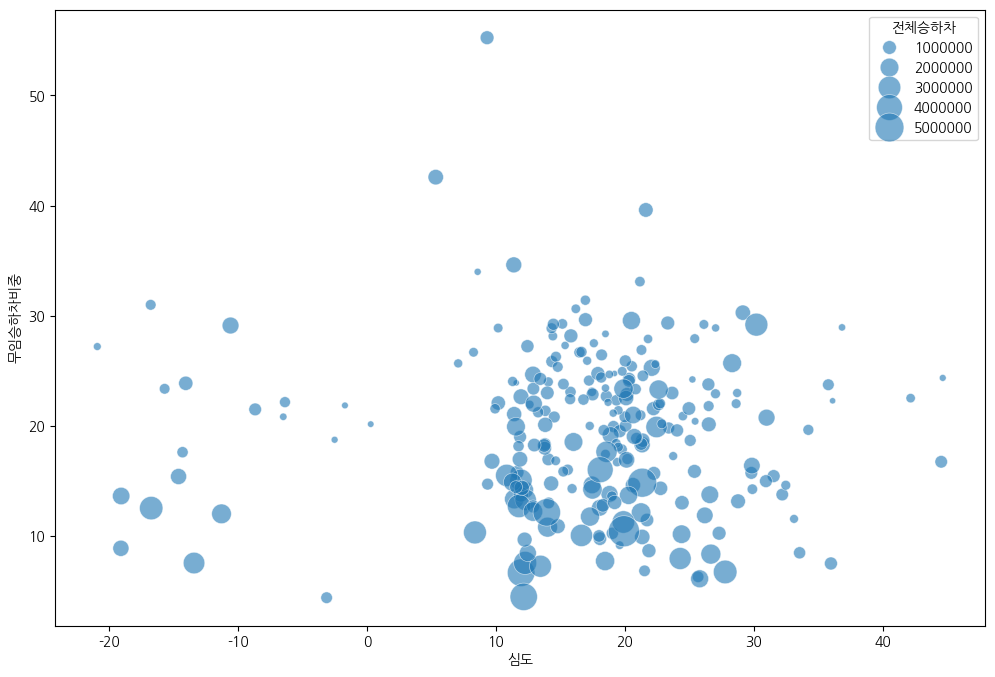

In [50]:
# 심도와 무임승하차비중 관계
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data = df_final_fixed,
    x = '심도',
    y = '무임승하차비중',
    size = '전체승하차',
    alpha = 0.6,
    sizes = (20, 500)
)

plt.show()

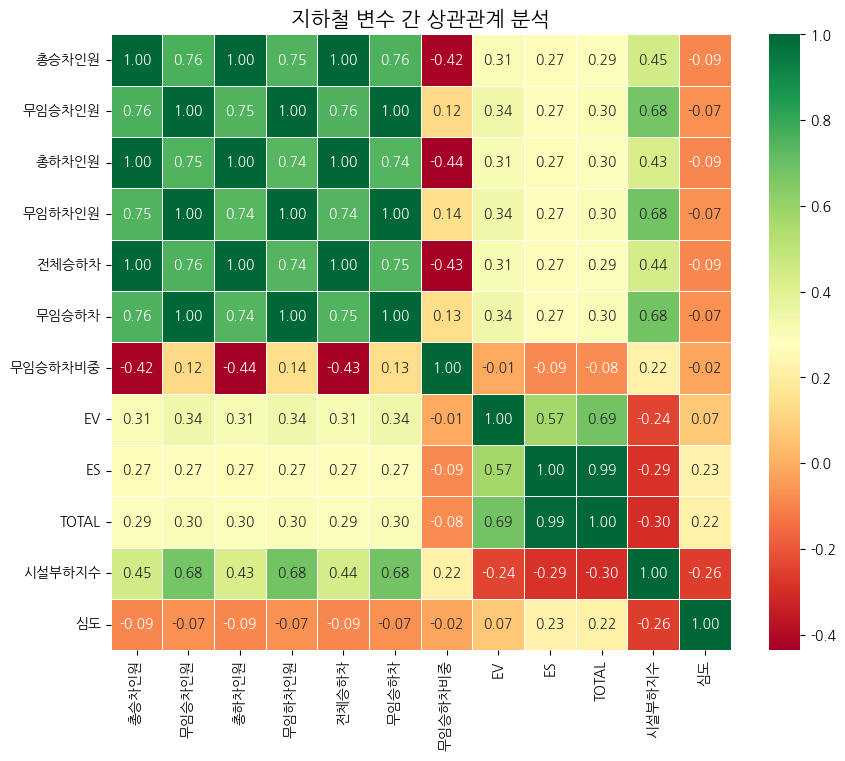

In [55]:
# 숫자형 컬럼만 추출해서 상관계수 히트맵으로 확인
plt.figure(figsize=(10, 8))
sns.heatmap(df_final_fixed.corr(numeric_only=True), annot=True, cmap='RdYlGn', fmt='.2f', linewidths=0.5)
plt.title('지하철 변수 간 상관관계 분석', fontsize=15)
plt.show()

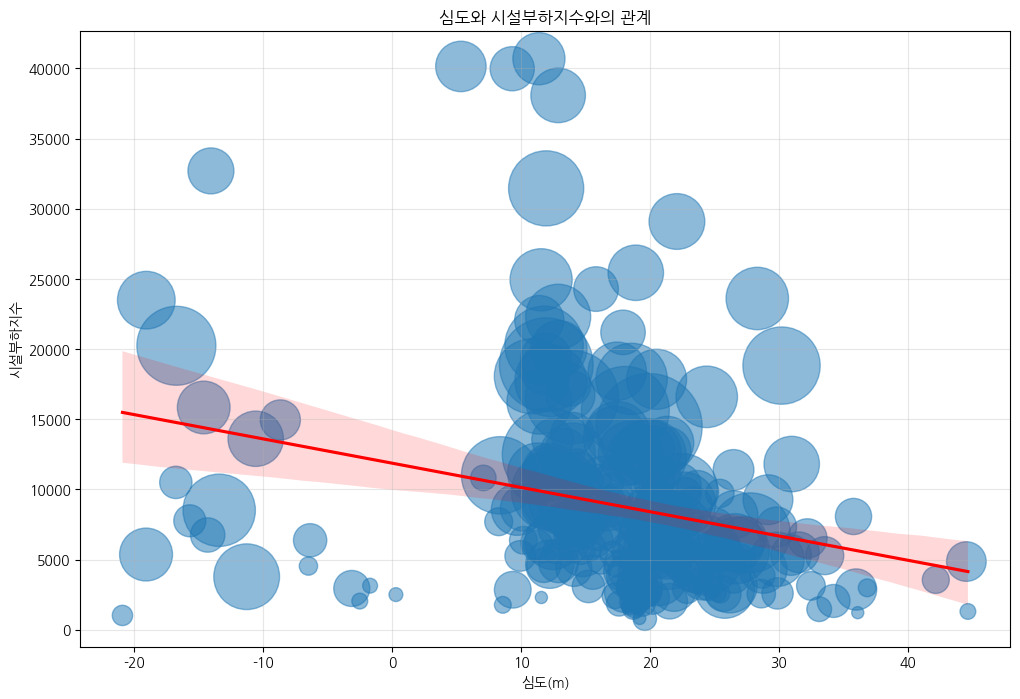

In [59]:
# 심도와 시설부하지수의 관계 시각화
plt.figure(figsize=(12, 8))
sns.regplot(
    data=df_final_fixed,
    x='심도',
    y='시설부하지수',
    scatter_kws={'alpha':0.5, 's':df_final_fixed['전체승하차']/1000}, # 이용객수에 따른 버블 크기
    line_kws={'color':'red'}
)

plt.title('심도와 시설부하지수와의 관계')
plt.xlabel('심도(m)')
plt.ylabel('시설부하지수')
plt.grid(True, alpha=0.3)
plt.show()

In [65]:
high_load_targets = middle_depth_df.nlargest(5, '시설부하지수')

display(high_load_targets[['지하철역', '호선명', '심도', '무임승하차', 'EV', 'ES', '시설부하지수']])

,지하철역,호선명,심도,무임승하차,EV,ES,시설부하지수
2,종로5가,1,11.39,488319,3,0,40693.25
3,청량리,1,5.34,561989,2,6,40142.07
0,제기동,1,9.32,559716,3,2,39979.71
65,미아사거리,4,12.88,380795,2,2,38079.50
18,선릉,2,11.95,440366,3,2,31454.71


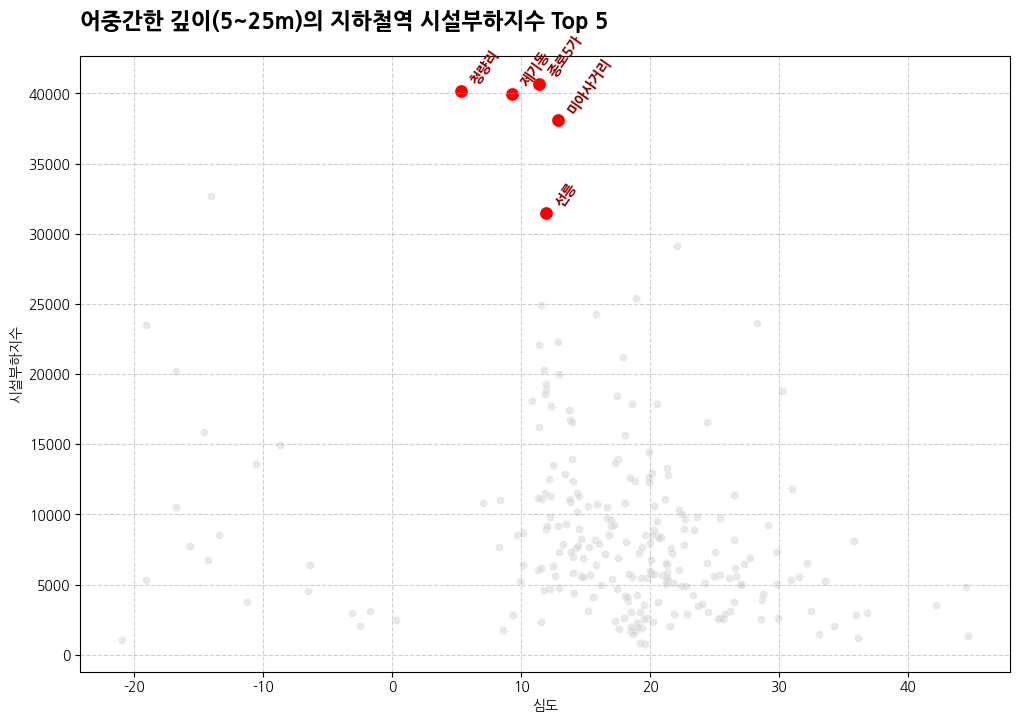

In [81]:
plt.figure(figsize=(12, 8))

# 2. 전체 데이터 산점도 (연한 회색으로 배경 처리)
sns.scatterplot(data=df_final_fixed, x='심도', y='시설부하지수', color='lightgray', alpha=0.5)

# 3. 강조하고 싶은 5개 역만 빨간색으로 다시 그리기
sns.scatterplot(data=high_load_targets, x='심도', y='시설부하지수', color='red', s=100)

# 4. ★ 핵심: 5개 역에 이름(텍스트) 달기
for i in range(len(high_load_targets)):
    plt.annotate(
        high_load_targets.iloc[i]['지하철역'],               # 표시할 텍스트
        (high_load_targets.iloc[i]['심도'], high_load_targets.iloc[i]['시설부하지수']), # 좌표
        textcoords="offset points",                         # 위치 기준
        xytext=(5, 5),                                      # 점으로부터의 거리 (x, y)
        ha='left',                                          # 수평 정렬
        fontsize=10,
        fontweight='bold',
        color='darkred',
        rotation=55
    )

plt.title('어중간한 깊이(5~25m)의 지하철역 시설부하지수 Top 5', fontsize=16, pad=20, loc='left', fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()